In [1]:
import os
import numpy as np
import pandas as pd
from prettytable import PrettyTable
from scipy.stats import chi2_contingency
from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
subgroups = pd.read_csv('../Data_Prep/subgroup_meta.csv', index_col=0)
subgroups = subgroups.set_index('PATNO')

In [16]:
events = ['BL', 'V02' , 'V04' ,'V05',
          'V06' ,'V07' , 'V08' ,'V09' , 'V10' ,
          'V11' , 'V12' ,'V13' , 'V14' ,'V15' ,
          'V16' , 'V17' , 'V18','V19' ,'V20' ]

all_events = ['SC', 'BL', 'V01', 'V02', 'V03', 'V04', 'V05',
'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12',
'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
'ST', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25'
]

x_list = pd.DataFrame(np.arange(0 , 9.5 , 0.5) , index = events , columns=['trajectory'])
events_df = pd.DataFrame()
for patno in subgroups.index.unique() : 
    df_tmp = pd.DataFrame({'PATNO' : [patno for i in range(len(events))] , 'EVENT_ID' : events})
    events_df = pd.concat([events_df , df_tmp])

events_df = pd.merge(events_df , x_list , left_on = 'EVENT_ID' ,right_index=True )

In [42]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.1)
    Q3 = df[column].quantile(0.9)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def format_as_contingency(df , event) : 
    # Create a pivot table to format data into a contingency table
    pivot_table = df.pivot(index='Group', columns=event, values='count')
    
    # Convert the pivot table to a PrettyTable
    pretty_table = PrettyTable()
    
    # Add column names (Assuming 'Worse' and 'Not Worse' are the columns after pivoting)
    pretty_table.field_names = ["Group", "Worse", "Not Worse"]
    
    # Add rows to the pretty table from pivot data
    for index, row in pivot_table.iterrows():
        # Row must be added as a list of elements
        pretty_table.add_row([index, row['Worse'], row['Not Worse']])
    
    # Print the PrettyTable
    print("Contingency Table:")
    return print(pretty_table)

# Defined function to handle pairwise comparison
def pairwise_proportion_test(counts, nobs, alpha=0.05):
    group_labels = ['Group 0', 'Group 1', 'Group 2']
    num_groups = len(counts)
    
    # Applying Bonferroni correction
    adjusted_alpha = alpha / num_groups
    
    print(f"Using a Bonferroni-corrected alpha value of {adjusted_alpha} \n" )
    
    for i in range(num_groups):
        for j in range(i + 1, num_groups):
            stat, p_val = proportions_ztest([counts[i], counts[j]], [nobs[i], nobs[j]])
            print(f"Comparison: {group_labels[i]} vs {group_labels[j]} - z-stat: {stat}, p-value: {p_val}")
            if p_val < adjusted_alpha:
                print(f"Significant difference between {group_labels[i]} and {group_labels[j]} at the {adjusted_alpha:.4f} significance level. \n")
            else:
                print(f"No significant difference between {group_labels[i]} and {group_labels[j]} at the {adjusted_alpha:.4f} significance level. \n")

def plot_regression_with_ci(x, y, color, label):
    # Fit the regression model
    X = sm.add_constant(x)  # Adds a constant term to the predictor
    model = sm.OLS(y, X).fit()

    # Get prediction std deviation and intervals
    prstd, iv_l, iv_u = wls_prediction_std(model)

    # Plotting
    plt.plot(x['trajectory'].values, y, 'o', color=color)
    plt.plot(x['trajectory'].values, model.predict(X), 'k-', color=color, label=f'{label}')
    plt.fill_between(x['trajectory'], iv_l, iv_u, color=color, alpha=0.05)

def data_availability_plot(data) : 
    fig , (ax1,ax2) = plt.subplots(figsize=(10,6) , ncols=2)
    pd.DataFrame(data.groupby('Group').count().values  / data.groupby('Group').size().values.reshape(-1,1) , index=  [0,1,2] , columns=data.columns[:-1]).T.plot(kind='line' , ax=ax1)
    ax1.set_title('Data Availability')
    ax1.set_ylabel('Proportion of Data Available')
    ax1.set_xlabel('Visit Number')

    pd.DataFrame(data.groupby('Group').mean()).T.plot(kind='line' , ax=ax2)
    ax2.set_title('Subgroup Averages')
    ax1.set_ylabel('Average Score')
    ax1.set_xlabel('Visit Number')
    
    plt.show()
    plt.clf()

def data_process(data , events , events_df,print_final_event=True) : 
    events_filt = sorted(list(set(events) & set(data.columns)))
    if print_final_event : 
        print(f'final event : {events_filt[-1]}')
    
    df_long = data.reset_index().melt(id_vars=['Group' ,'PATNO'], var_name='EVENT_ID', value_name='Status')
    
    df_long = df_long.dropna(subset= ['Status'])
    
    df_long = pd.merge(df_long , subgroups.reset_index() , left_on = ['PATNO' , 'EVENT_ID' , 'Group'],right_on =['PATNO' , 'EVENT_ID' , 'Group'] , how='outer')
    
    df_long = pd.merge(df_long , events_df , on =['PATNO' , 'EVENT_ID'] , how='outer')
    
    df_long = df_long[df_long['EVENT_ID'].isin(events_filt)]
    
    # Combined linear model, including interaction between predictor and group
    df_long['Group'] = pd.Categorical(df_long['Group'], categories=[0,1,2], ordered=True)

    return df_long

def ols_model_plots(model) : 
    fitted_vals = model.predict()
    residuals = model.resid
    
    fig, (ax1,ax2) = plt.subplots(figsize=(10, 6) , ncols=2)
    ax1.scatter(fitted_vals, residuals, alpha=0.5)
    ax1.axhline(0, color='red', linestyle='--')
    ax1.set_xlabel('Fitted Values')
    ax1.set_ylabel('Residuals')
    ax1.set_title('Residuals vs Fitted Values')
    
    sm.qqplot(residuals, line='s', ax=ax2)  # 's' indicates standardized line
    ax2.set_title('Q-Q Plot of Residuals')
    plt.show()

def gen_patient_class(df_long , model , data) : 
    # Group data by PatientID, and fit a regression model for each group
    slopes = {}
    
    for patient_id, group in df_long.groupby('PATNO'):
        x = group['trajectory']
        y = group['Status'] - model.params['Intercept'] #- (model.params['AGE_AT_VISIT']*group['AGE_AT_VISIT']) - (model.params['GENDER']*group['GENDER'])
        slopes[patient_id] = np.polyfit(x, y, 1, full=False)[0] 
    
    threshold = (model.params[3] + model.params[4])*0.34 + (model.params[3] + model.params[5])*0.33 + model.params[3]*0.33
    data['Class'] = ['Worse' if slopes[patient] > threshold else 'Not Worse' for patient in data.index]
    data['Slope'] = [slopes[patient] for patient in data.index]
    
    data['Class'] = pd.Categorical(data['Class'] , categories=['Worse' , 'Not Worse'] , ordered=True)
    data_test = data.groupby(['Group','Class'], observed=False)['Class'].value_counts().reset_index().sort_values(['Group' , 'Class'])['count'].to_numpy().reshape(-1,2)

    return data, data_test

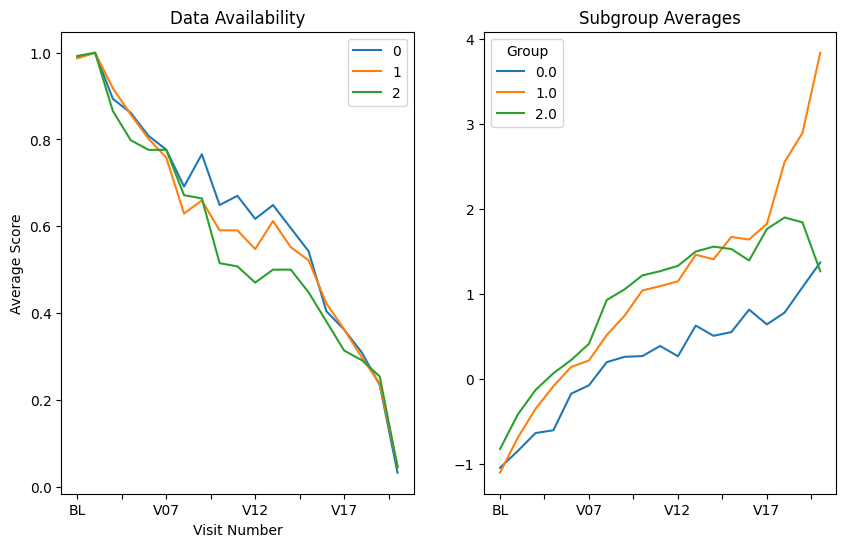

final event : V20


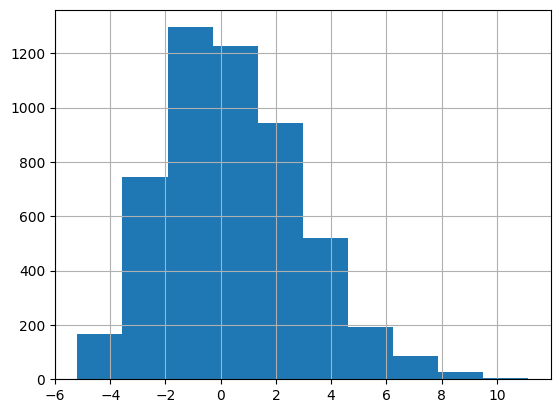

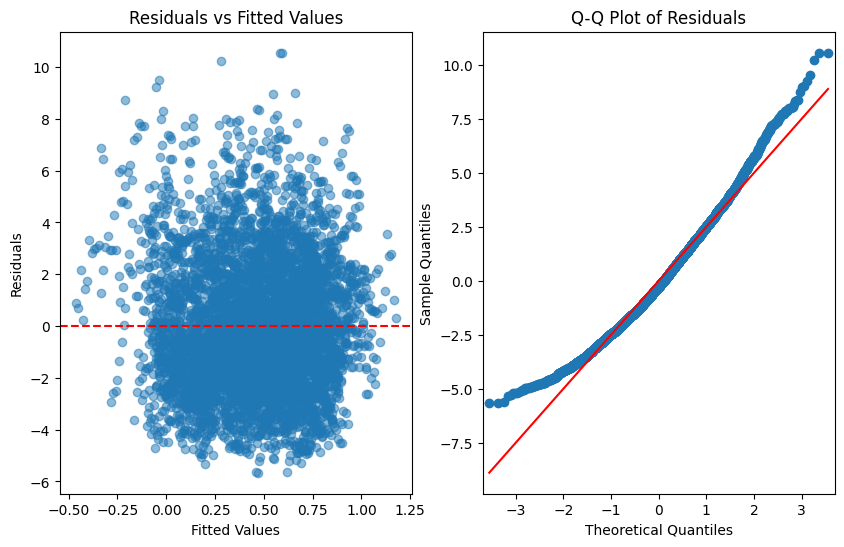

                            OLS Regression Results                            
Dep. Variable:                 Status   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     30.52
Date:                Tue, 13 May 2025   Prob (F-statistic):           6.63e-14
Time:                        11:55:36   Log-Likelihood:                -12144.
No. Observations:                5200   AIC:                         2.429e+04
Df Residuals:                    5197   BIC:                         2.431e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.2492      0.239     -5.226   

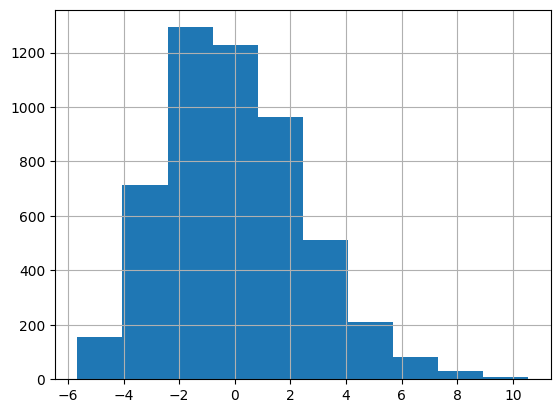

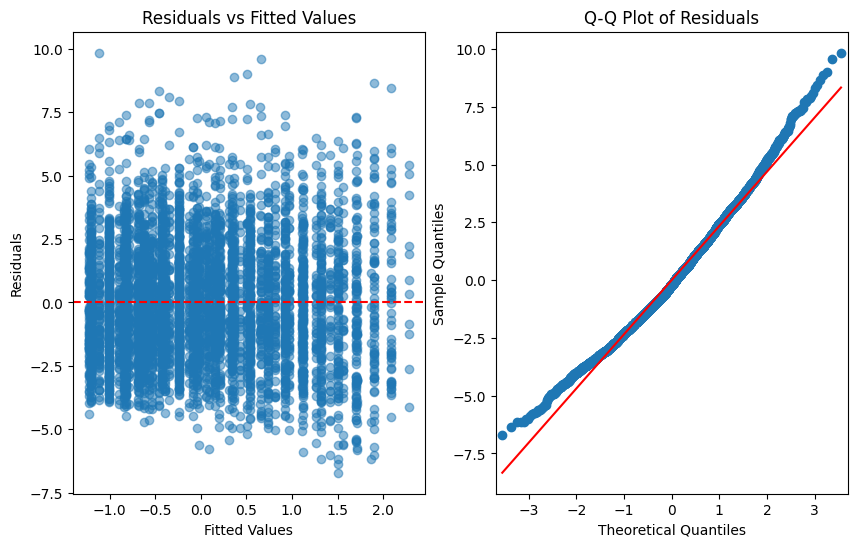

Contingency Table:
+-------+-------+-----------+
| Group | Worse | Not Worse |
+-------+-------+-----------+
|  0.0  |   40  |     54    |
|  1.0  |  143  |     89    |
|  2.0  |   63  |     71    |
+-------+-------+-----------+

Using a Bonferroni-corrected alpha value of 0.016666666666666666 

Comparison: Group 0 vs Group 1 - z-stat: -3.1456427117104413, p-value: 0.0016572232067397115
Significant difference between Group 0 and Group 1 at the 0.0167 significance level. 

Comparison: Group 0 vs Group 2 - z-stat: -0.6663674795565545, p-value: 0.5051762436066185
No significant difference between Group 0 and Group 2 at the 0.0167 significance level. 

Comparison: Group 1 vs Group 2 - z-stat: 2.716939582331533, p-value: 0.0065888634200586115
Significant difference between Group 1 and Group 2 at the 0.0167 significance level. 



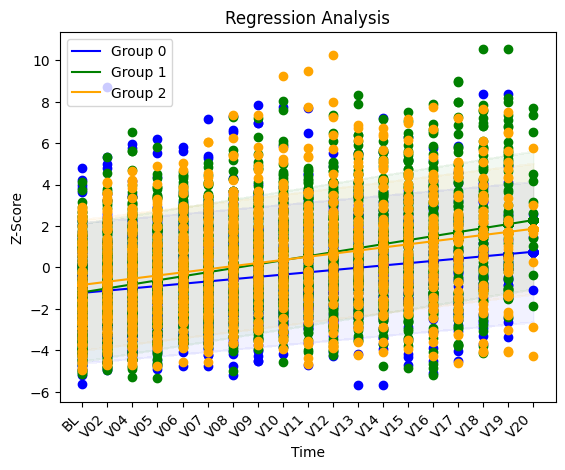

In [43]:
df = pd.read_csv('./../Labels/FA_MDS-UPDRS.csv' , index_col=0)

df['combo'] = df.loc[: , ('MDS_UPDRS_P1_Factor_1','MDS_UPDRS_P3_Factor_1', 'MDS_UPDRS_P3_Factor_4' , 'MDS_UPDRS_P3_Factor_5')
].sum(axis=1)
data = df.pivot_table(values = 'combo', columns = 'EVENT_ID' , index = 'PATNO' , observed=False)
data = pd.merge(data , subgroups.reset_index()[['PATNO' , 'Group']].drop_duplicates() , left_index=True , right_on='PATNO').set_index('PATNO')

data_availability_plot(data)

events_filt = events
df_long = data_process(data , events_filt , events_df)

df_long['Status'].hist()
df_long['Group'] = pd.Categorical(df_long['Group'], categories=[0,1,2], ordered=True)
model = smf.ols('Status ~  AGE_AT_VISIT + GENDER', data=df_long.dropna()).fit()
ols_model_plots(model)
print(model.summary())
#df_long['Status'] = np.sqrt(model.resid + abs(min(model.resid)) + 1)
df_long['Status'] = model.resid
df_long['Status'].hist()
model = smf.ols('Status ~  trajectory * C(Group)', data=df_long.dropna()).fit()

print( model.params[3] - model.conf_int().iloc[3])

print(model.params[3] + model.params[4])
print( model.params[4] - model.conf_int().iloc[4])

print(model.params[3] + model.params[5])
print( model.params[5] - model.conf_int().iloc[5])

print(model.summary())
ols_model_plots(model)

df_long['Status'] = df_long['Status'].fillna(model.predict(df_long))
data, data_test = gen_patient_class(df_long , model , data)

data = data[events_filt + list(data.columns[-3:])]
format_as_contingency(data.groupby('Group', observed=False)['Class'].value_counts().reset_index().sort_values(['Group' , 'Class']) , 'Class')
print()

counts = data_test[: , 0]       # Number of vaccinated in each group
nobs = np.sum(data_test , 1)    # Total people in each group

pairwise_proportion_test(counts, nobs)

# Note: To keep color consistency among groups
colors = ['blue', 'green','orange']

for i , group in enumerate([0,1,2]) : 
    x = df_long[df_long['Group'] == group][['trajectory']]
    y = df_long[df_long['Group'] == group]['Status']
    plot_regression_with_ci(*(x,y), color=colors[i], label=f'Group {group}')

# Additional Plot Settings
plt.xlabel('Time')
plt.ylabel('Z-Score')
plt.xticks(ticks=np.unique(x['trajectory']), labels=sorted(events_filt), rotation=45, ha='right')
plt.title('Regression Analysis')
plt.legend()
plt.show()

In [44]:
data.reset_index()[['PATNO', 'Group' ,'Class']].to_csv('./../../data/PPMI/02_working/GIMR/BRef_Class_Labels.csv')

In [ ]:
Contingency Table:
+-------+-------+-----------+
| Group | Worse | Not Worse |
+-------+-------+-----------+
|  0.0  |   40  |     54    |
|  1.0  |  143  |     89    |
|  2.0  |   63  |     71    |
+-------+-------+-----------+